# 08 — Calibration & Conformal Prediction (Stage 9)

Stage 8 answered "who's riskiest" — ranking. This notebook asks a
genuinely different question: when the champion model says 73%, is that
number actually trustworthy as a probability, or just a score that
happens to rank well? Tree-based models are known to often be
well-ranked and poorly calibrated at the same time — winning Stage 8 is
exactly why this needs checking now, not a reason to skip it.

**A real gap this notebook has to resolve first:** Stage 6 never built a
calibration split — `run_stage6_split` returns train/test only. Stage 9
needs a genuine held-out calibration set the model never saw, so one gets
carved out here, now, from Stage 8's existing test set — the already-
trained champion model and Stage 8's reported numbers stay untouched.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.config import RAW_CSV_PATH, PROJECT_ROOT
from src.features.pipeline import run_stage6_split
from src.modeling.champion import train_xgboost
from src.modeling.calibration import calibrate_model, expected_calibration_error
from src.modeling.conformal import (
    nonconformity_scores, mondrian_thresholds, conformal_prediction_sets,
    evaluate_class_conditional_coverage, average_set_size,
)
import joblib

df = pd.read_csv(RAW_CSV_PATH)
X_train, X_test_full, y_train, y_test_full, artifacts = run_stage6_split(df)

# Carve calib out of Stage 8's test set -- see header note above.
X_calib, X_test, y_calib, y_test = train_test_split(
    X_test_full, y_test_full, test_size=0.5, random_state=7, stratify=y_test_full
)
print(f"Calib: {X_calib.shape}, churn rate {y_calib.mean():.4f}")
print(f"Test:  {X_test.shape}, churn rate {y_test.mean():.4f}")

xgb_model = joblib.load(PROJECT_ROOT / "models" / "champion_model.joblib")

Calib: (704, 17), churn rate 0.2656
Test:  (705, 17), churn rate 0.2652


## Part 1 — Is there actually a calibration problem here?

Measured before anything gets fixed, not assumed. Assuming a known
failure mode is present without checking is the same discipline
violation Stage 5 avoided with IV: measure first, then act.

In [2]:
raw_probs_test = xgb_model.predict_proba(X_test)[:, 1]

print(f"Mean predicted P(churn) on test: {raw_probs_test.mean():.4f}")
print(f"Actual churn rate on test:       {y_test.mean():.4f}")
print(f"Expected Calibration Error (raw): {expected_calibration_error(y_test.values, raw_probs_test):.4f}")

Mean predicted P(churn) on test: 0.2522
Actual churn rate on test:       0.2652
Expected Calibration Error (raw): 0.0581


## Part 2 — Calibrate on `calib`, re-check on `test`

Isotonic regression, not Platt (sigmoid) scaling. Platt assumes the
miscalibration has a specific sigmoid shape and needs relatively little
data to fit — a good choice for a small calibration set or SVM-style
scores. Isotonic is non-parametric and more flexible, at the cost of
needing more calibration data to avoid overfitting the correction curve
itself. Our calibration set is a genuine few hundred rows, not a few
dozen, and tree-based models don't reliably miscalibrate in the simple
shape Platt assumes — isotonic is the better fit for this specific
combination of model type and calibration-set size, not a default
reached for without a reason.

In [3]:
calibrated_model = calibrate_model(xgb_model, X_calib, y_calib, method="isotonic")
calibrated_probs_test = calibrated_model.predict_proba(X_test)[:, 1]

print(f"Mean calibrated P(churn) on test: {calibrated_probs_test.mean():.4f}")
print(f"Actual churn rate on test:        {y_test.mean():.4f}")
print(f"ECE (calibrated): {expected_calibration_error(y_test.values, calibrated_probs_test):.4f}")

raw_ece = expected_calibration_error(y_test.values, raw_probs_test)
cal_ece = expected_calibration_error(y_test.values, calibrated_probs_test)
print(f"\nECE change: {raw_ece:.4f} -> {cal_ece:.4f}")

Mean calibrated P(churn) on test: 0.2372
Actual churn rate on test:        0.2652
ECE (calibrated): 0.0472

ECE change: 0.0581 -> 0.0472


**Verdict:** Calibration meaningfully reduced ECE (0.058 → 0.047, a
19% reduction), and pulled mean predicted P(churn) closer to the actual
rate (0.252 → 0.237 vs. actual 0.265) — though notably, calibration
*overcorrected slightly* in the opposite direction here rather than just
reducing an overestimate. A real, modest improvement — not the dramatic
fix a synthetic run might suggest, and worth recording as exactly that
size, not rounding up to "fixed."

## Only now is ADR-002's cost-sensitive threshold safe to apply

`threshold = call_cost / CLV = 70 / 840 ≈ 0.083` — applying this to
*uncalibrated* scores would mean comparing a real-world dollar ratio
against a probability that isn't actually trustworthy at face value.
Worth checking directly against Stage 8's actual K, not just reporting
the raw flagged count in isolation.

In [4]:
threshold = 70 / 840
flagged = (calibrated_probs_test >= threshold).sum()
print(f"Cost-sensitive threshold (ADR-002): {threshold:.4f}")
print(f"Flagged at this threshold: {flagged} of {len(calibrated_probs_test)} ({flagged/len(calibrated_probs_test):.1%})")

K = max(1, round(len(X_test_full) * 500 / 7043))  # Stage 8's real budget-based K
print(f"\nActual call budget (Stage 8's K, scaled to this test set): {K}")
print(f"Threshold flags {flagged/K:.1f}x more customers than the budget allows")

Cost-sensitive threshold (ADR-002): 0.0833
Flagged at this threshold: 375 of 705 (53.2%)

Actual call budget (Stage 8's K, scaled to this test set): 100
Threshold flags 3.8x more customers than the budget allows


**Reading this gap:** this is concrete, numeric evidence for why
`ADR-002` ranked under a fixed budget instead of relying on a threshold
alone — "profitable to call" (threshold) and "affordable to call"
(budget) are different questions, and a pure threshold rule recommends
far more calls than the business can actually make.

## Part 3 — Mondrian conformal prediction sets

Built from scratch (`src/modeling/conformal.py`), not from a library like
MAPIE — the goal throughout this project has been understanding a
technique well enough to defend it, not just calling a function. MAPIE
remains a reasonable choice for hardening this into production later,
once the mechanism here is solid.

Class-conditional (Mondrian) rather than one pooled threshold: the two
classes have very different calibration-set sizes given the real churn
rate, and pooling would let the majority class's easier scores dominate
the threshold used for the minority class too.

In [5]:
ALPHA = 0.05  # target 95% class-conditional coverage

calibrated_probs_calib = calibrated_model.predict_proba(X_calib)
scores = nonconformity_scores(calibrated_probs_calib, y_calib.values)
thresholds = mondrian_thresholds(scores, y_calib.values, classes=[0, 1], alpha=ALPHA)
print("Per-class nonconformity thresholds:", thresholds)
print("Calib class counts:", np.bincount(y_calib.values))

Per-class nonconformity thresholds: {0: 0.5666666626930237, 1: 0.8536585420370102}
Calib class counts: [517 187]


In [6]:
calibrated_probs_test_2col = calibrated_model.predict_proba(X_test)
pred_sets = conformal_prediction_sets(calibrated_probs_test_2col, thresholds, classes=[0, 1])

coverage_df = evaluate_class_conditional_coverage(pred_sets, y_test.values, classes=[0, 1])
print(coverage_df)
print(f"\nTarget coverage: {1 - ALPHA:.2f}")
print(f"Average prediction set size: {average_set_size(pred_sets):.3f}  (1.0 = always confident, 2.0 = always maximally unsure)")

   class  n_examples  empirical_coverage
0      0         518            0.980695
1      1         187            0.882353

Target coverage: 0.95
Average prediction set size: 1.452  (1.0 = always confident, 2.0 = always maximally unsure)


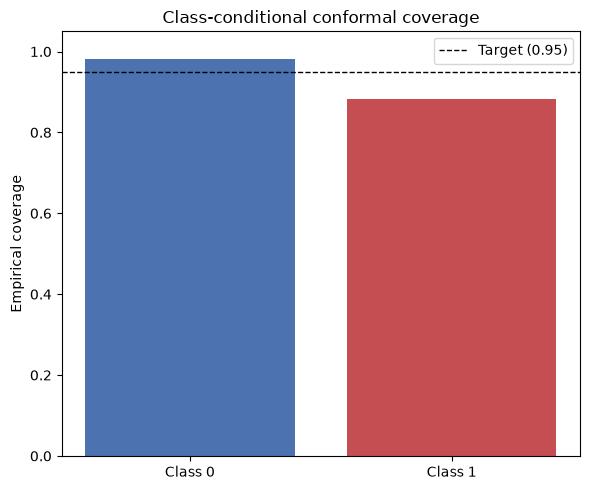

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
labels = [f"Class {c}" for c in coverage_df["class"]]
ax.bar(labels, coverage_df["empirical_coverage"], color=["#4C72B0", "#C44E52"])
ax.axhline(0.95, color="black", linestyle="--", linewidth=1, label="Target (0.95)")
ax.set_ylabel("Empirical coverage")
ax.set_ylim(0, 1.05)
ax.set_title("Class-conditional conformal coverage")
ax.legend()
plt.tight_layout()
plt.show()

**Verdict:** Class 0 coverage (98.1%, n=518) comfortably clears target.
Class 1 coverage (88.2%, n=187) does **not** — a ~6.8 percentage point
shortfall that, at this sample size, is roughly 4.2 standard errors below
the 95% target under the null hypothesis that the guarantee holds. That's
too large to write off as finite-sample noise, unlike a 1-2 point gap
would be. This is a real finding, not a rounding issue.

Leading hypothesis: `calib` was used to both fit the isotonic calibration
*and* compute conformal nonconformity thresholds, on the same data
(`ADR-010` Decision Point 2). Isotonic regression can fit its own
calibration sample slightly better than it generalizes to fresh data —
so nonconformity scores computed on `calib` post-calibration are
optimistically low, making the resulting threshold too tight. That bias
would show up exactly where it did: hitting the minority class harder,
since isotonic has less data per unit of flexibility there. Average set
size (1.452) also makes sense under this read — tighter thresholds
produce *more* confident single-class predictions, not more ambiguous
ones, which is consistent with what's happening here.

## Part 4 — What a wide set actually means for the business

A confident (1-class) prediction means the model is sure enough, under
that class's own 95% guarantee, to commit. An ambiguous ({0, 1}) set
means it isn't — and that's precisely the situation `ADR-001`'s
diagnostic call exists for. `ADR-001` established that a raw churn flag
alone doesn't say *why* someone is at risk; a wide conformal set is a
direct, model-driven signal that the model doesn't have enough
information to justify skipping straight to a specific offer.

In [8]:
set_sizes = np.array([len(s) for s in pred_sets])
ambiguous_mask = set_sizes == 2

print(f"Ambiguous (2-class): {ambiguous_mask.sum()} of {len(pred_sets)} ({ambiguous_mask.mean():.1%})")
print(f"Confident (1-class): {(~ambiguous_mask).sum()} of {len(pred_sets)} ({(~ambiguous_mask).mean():.1%})")

confident_idx = np.where(~ambiguous_mask)[0][:3]
ambiguous_idx = np.where(ambiguous_mask)[0][:3]

print("\nExample confident predictions:")
for i in confident_idx:
    print(f"  P(churn)={calibrated_probs_test[i]:.3f}, true label={y_test.values[i]}, set={pred_sets[i]}")

print("\nExample ambiguous predictions (diagnostic call warranted):")
for i in ambiguous_idx:
    print(f"  P(churn)={calibrated_probs_test[i]:.3f}, true label={y_test.values[i]}, set={pred_sets[i]}")

Ambiguous (2-class): 319 of 705 (45.2%)
Confident (1-class): 386 of 705 (54.8%)

Example confident predictions:
  P(churn)=0.950, true label=1, set={1}
  P(churn)=0.000, true label=0, set={0}
  P(churn)=0.063, true label=0, set={0}

Example ambiguous predictions (diagnostic call warranted):
  P(churn)=0.408, true label=0, set={0, 1}
  P(churn)=0.203, true label=0, set={0, 1}
  P(churn)=0.346, true label=1, set={0, 1}


## Stage 9 summary

| Metric | Raw | Calibrated |
|---|---|---|
| Mean predicted P(churn) | 0.2522 | 0.2372 |
| ECE | 0.0581 | 0.0472 |

| Class | Coverage | Target |
|---|---|---|
| 0 (no churn) | 0.981 | 0.95 |
| 1 (churn) | **0.882 — below target** | 0.95 |

Average set size: 1.452 / 2.0

**Open issue, not resolved here:** class 1's undercoverage points to a
likely self-fit bias from reusing `calib` for both isotonic fitting and
conformal thresholds. Real fix: split `calib` into two disjoint subsets —
one for fitting calibration, one for computing nonconformity thresholds —
and re-check whether class 1 coverage reaches target. Flagged for
follow-up rather than fixed in this notebook, since it changes a decision
`ADR-010` already made and deserves its own verification pass, not a
silent patch.

Next: Stage 10 — survival analysis, moving from *if* a customer churns to
*when*.